In [ ]:
import numpy as np
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def run_simulation_figure_2b(path_bin, amplitude_S2):

    dt = 5/60
    nz, ntrials = 100, 100
    elevation = np.linspace(-2, 2, nz)[::-1]
    amplitude_annual_cycle = np.linspace(0, 2.0, ntrials)
    avg_max_inundation_duration = np.array([np.nan]*nz*ntrials).reshape(nz, ntrials)
    avg_max_emergent_duration   = np.array([np.nan]*nz*ntrials).reshape(nz, ntrials)
    for i in range(ntrials):
        
        _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle[i], mean_waterlevel = 0., n_years = 2, amplitude_S2 = amplitude_S2, sigma = 0., dt = dt)
        avg_max_inundation_duration[:,i], avg_max_emergent_duration[:,i] = f.find_avg_max_duration(elevation, waterlevel, dt)
        print(f'{i+1}/{ntrials}')
        
    # Tile input parameters for saving
    elevation_tiled = np.tile(elevation[:,None], reps = (1, ntrials))
    amplitude_annual_cycle_tiled = np.tile(amplitude_annual_cycle[None,:], reps = (nz, 1))

    np.save(path_bin, [elevation_tiled, amplitude_annual_cycle_tiled, avg_max_inundation_duration, avg_max_emergent_duration])

#################
## Run simulation (Takes time, don't re-run on accident)
#################

# for amplitude_S2 in [0.70, 0.40, 0.15]:
#     run_simulation_figure_2b(path_bin = f'./bin/supp_note_1/figure_s1/alt/figure_s1-alt_S2M2={amplitude_S2}.npy', amplitude_S2 = amplitude_S2)


1/100
2/100
3/100
4/100
5/100
6/100
7/100
8/100
9/100
10/100
11/100
12/100
13/100
14/100
15/100
16/100
17/100
18/100
19/100
20/100
21/100
22/100
23/100
24/100
25/100
26/100
27/100
28/100
29/100
30/100
31/100
32/100
33/100
34/100
35/100
36/100
37/100
38/100
39/100
40/100
41/100
42/100
43/100
44/100
45/100
46/100
47/100
48/100
49/100
50/100
51/100
52/100
53/100
54/100
55/100
56/100
57/100
58/100
59/100
60/100
61/100
62/100
63/100
64/100
65/100
66/100
67/100
68/100
69/100
70/100
71/100
72/100
73/100
74/100
75/100
76/100
77/100
78/100
79/100
80/100
81/100
82/100
83/100
84/100
85/100
86/100
87/100
88/100
89/100
90/100
91/100
92/100
93/100
94/100
95/100
96/100
97/100
98/100
99/100
100/100
1/100
2/100
3/100
4/100
5/100
6/100
7/100
8/100
9/100
10/100
11/100
12/100
13/100
14/100
15/100
16/100
17/100
18/100
19/100
20/100
21/100
22/100
23/100
24/100
25/100
26/100
27/100
28/100
29/100
30/100
31/100
32/100
33/100
34/100
35/100
36/100
37/100
38/100
39/100
40/100
41/100
42/100
43/100
44/100
45/100
46

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


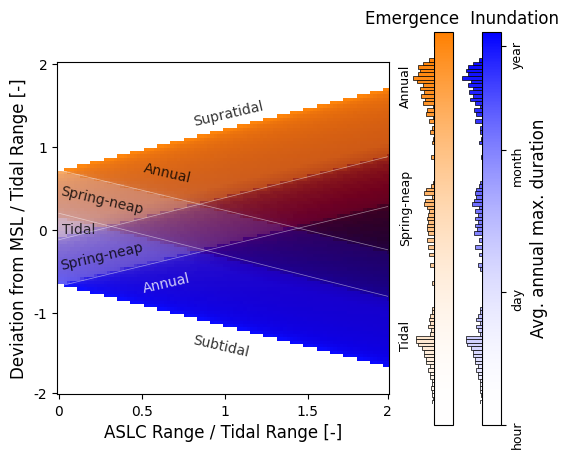

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


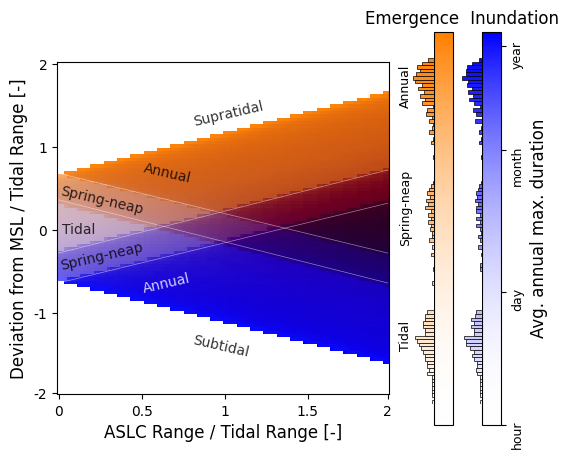

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


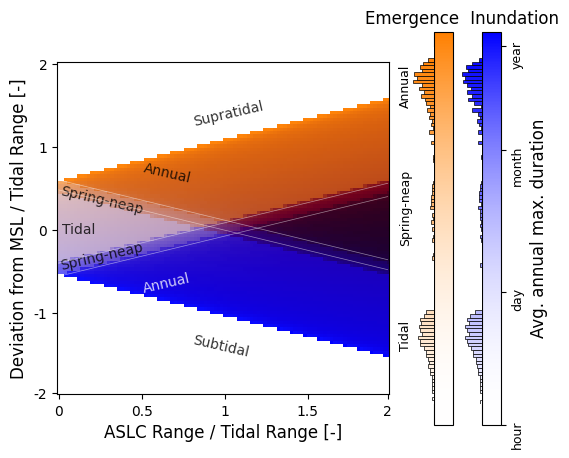

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle

def plot_figure_2b(fig, ax, path_bin):
    
    def blend_arrays(array0, array1, xmin, xmax):

        array0, array1 = np.log10(array0), np.log10(array1)
        
        # Normalize arrays between 0 and 1
        a0 = (array0 - xmin) / (xmax - xmin)
        a1 = (array1 - xmin) / (xmax - xmin)
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0 
        a0[a0 > 1] = 1
        a1[a1 > 1] = 1 
        a0[a0 < 0] = 0
        a1[a1 < 0] = 0 

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 0] -= a0   # Red channel = array1
        rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        return rgb

    def add_zone_boundaries(ax, path_bin):

        z, aslc, inund_max, emerg_max = np.load(path_bin)
        ntrials = aslc.shape[1]

        tidal, spring_neap, annual = 12.25/24, 29.6, 365.25

        sn_inund_boundary = np.argmin(inund_max < tidal, axis = 0)
        annual_inund_boundary = np.argmin(inund_max < spring_neap, axis = 0)
        annual_emerg_boundary = np.argmax(emerg_max < spring_neap, axis = 0) - 1
        sn_emerg_boundary = np.argmax(emerg_max < tidal, axis = 0) - 2

        start, end = 0, ntrials - 1

        ax.plot([start, end], [sn_inund_boundary[start],sn_inund_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [annual_inund_boundary[start],annual_inund_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [sn_emerg_boundary[start],sn_emerg_boundary[end]], c = (1,1,1,0.5), lw = 0.5)
        ax.plot([start, end], [annual_emerg_boundary[start],annual_emerg_boundary[end]], c = (1,1,1,0.5), lw = 0.5)

    def add_colorbars(fig, ax, xmin, xmax):
        # Create colorbars
        white  = (1.0, 1.0, 1.0, 0.0)
        blue   = (0.0, 0.0, 1.0, 1.0)
        orange = (1.0, 0.5, 0.0, 1.0)

        cmap0 = LinearSegmentedColormap.from_list("white_to_blue", [white, blue])
        cmap1 = LinearSegmentedColormap.from_list("white_to_orange", [white, orange])

        norm = plt.Normalize(vmin = xmin, vmax = xmax)
        mappable_inund = ScalarMappable(norm=norm, cmap=cmap0)
        mappable_emerg = ScalarMappable(norm=norm, cmap=cmap1)
        
        # Add colorbars using dummy mappables
        cbar0 = fig.colorbar(mappable_inund, ax = ax)
        cbar0.ax.set_ylabel('Avg. annual max. duration', fontsize=12)
        cbar0.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'], fontsize = 9)
        pos = cbar0.ax.get_position()
        new_pos = [pos.x0 - 0.025, pos.y0, pos.width, pos.height]
        cbar0.ax.set_position(new_pos)
        cbar0.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar0.ax.set_title('         Inundation', fontsize=12)

        cbar1 = fig.colorbar(mappable_emerg, ax=ax)
        cbar1.ax.set_yticks(ticks = [])
        cbar1.ax.tick_params(axis = 'y', labelrotation = 90)
        cbar1.ax.set_title('Emergence            ', fontsize=12)
        pos = cbar1.ax.get_position()
        new_pos = [pos.x0 + 0.035, pos.y0, pos.width, pos.height]
        cbar1.ax.set_position(new_pos)

        return cbar0, cbar1

    def add_inund_colorbar_historgram(cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax0 = fig.add_axes([0.729, 0.15, 0.03, 0.7])

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax0.transData, facecolor = (1 - a1,1 - a1,1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax0.add_patch(rect)

        hist_ax0.set_ylim(cbar.ax.get_ylim()) 
        hist_ax0.set_xticks([])
        hist_ax0.set_yticks([])
        hist_ax0.set_xlim(0, 1)
        hist_ax0.invert_xaxis()
        for spine in hist_ax0.spines.values():
            spine.set_visible(False)

    def add_emerg_colorbar_historgram(cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax1 = fig.add_axes([0.657, 0.15, 0.03, 0.7])

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax1.transData, facecolor = (1,1 - a1*0.5,1 - a1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax1.add_patch(rect)

        hist_ax1.text(x = 1.4, y = np.log10(6.125/24), s = 'Tidal', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(14.8/2), s = 'Spring-neap', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')
        hist_ax1.text(x = 1.4, y = np.log10(365.25/2), s = 'Annual', rotation = 90, fontsize = 9, verticalalignment = 'center', horizontalalignment = 'center')

        hist_ax1.set_ylim(cbar.ax.get_ylim())
        hist_ax1.set_xticks([])
        hist_ax1.set_yticks([])
        hist_ax1.set_xlim(0, 1)
        hist_ax1.invert_xaxis()
        for spine in hist_ax1.spines.values():
            spine.set_visible(False)

    z, aslc, inund_max, emerg_max = np.load(path_bin)

    inund_max[inund_max == 0] = np.nan
    emerg_max[emerg_max == 0] = np.nan
    subset = np.isnan(inund_max) | np.isnan(emerg_max)
    inund_max[subset] = np.nan
    emerg_max[subset] = np.nan

    xmin, xmax = np.log10(1/24), np.log10(365.25*1.4)

    rgb = blend_arrays(inund_max, emerg_max, xmin, xmax)
    ax.imshow(rgb, vmin = xmin, vmax = xmax)
    add_zone_boundaries(ax, path_bin)

    cbar0, cbar1 = add_colorbars(fig, ax, xmin, xmax)
    add_inund_colorbar_historgram(cbar0, inund_max, xmin, xmax)
    add_emerg_colorbar_historgram(cbar1, emerg_max, xmin, xmax)

    ax.set_xlabel('ASLC Range / Tidal Range [-]', fontsize = 12)
    ax.set_ylabel('Deviation from MSL / Tidal Range [-]', fontsize = 12)
    ax.set_xticks(ticks = [0, 25, 50, 75, 99], labels = [0, 0.5, 1, 1.5, 2])
    ax.set_yticks(ticks = [0, 25, 50, 75, 99], labels = [2, 1, 0, -1, -2])

    ax.text(40, 15, s = 'Supratidal',  rotation =  13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(25, 33, s = 'Annual',      rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 0, 41, s = 'Spring-neap', rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 1, 50, s = 'Tidal',       rotation =   0, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 0, 58, s = 'Spring-neap', rotation =  13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(25, 66, s = 'Annual',      rotation =  13, c = 'white', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(40, 85, s = 'Subtidal',    rotation =  -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)

def figure_multipanel_figure_2(path_bin, path_png = None):

    rows, cols = 1, 1
    fig = plt.figure(figsize=((6.4 + 0.3)*cols,(4.8 + 0.3)*rows))
    gs = fig.add_gridspec(rows, cols, hspace=.15, wspace=.15) 

    ax = fig.add_subplot(gs[0,0])
    plot_figure_2b(fig, ax, path_bin)
    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

for amplitude_S2 in [0.70, 0.40, 0.15]:
    figure_multipanel_figure_2(path_bin = f'./bin/supp_note_1/figure_s1/alt/figure_s1-alt_S2M2={amplitude_S2}.npy', path_png = None)
